# Maze-ND substrate: generate data and display figures

TODO


artifact   : artifact:maze-nd/source-topology/v1
schema     : raster-topology/v1
total rows : 2000
inspect id : sha256:00296667ede3dfe87cb1759647065fbb597791c55a6573250009be48144f5a29
projection_identity: sha256:93df2b60dedc1b3fb1b27c27edaef83c201d2270cec1e7f93bbb5cdc0e0076b6


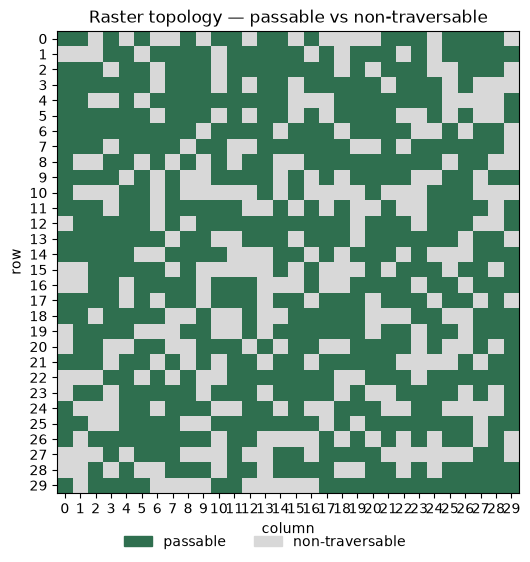

In [1]:
%matplotlib inline
from pathlib import Path

from ehp_sn.artifacts import load_release
from ehp_sn.figures import inspect_figure

# Resolve the committed artifact and choose a deterministic record.
# Record selection is deterministic: sort by canonical record_id, independent
# of build/enumeration order (projection.md "Deterministic selection").
artifact_dir = Path("data/interim/maze-nd/source-topology/v1")
artifact = load_release(artifact_dir)

records = sorted(artifact.records, key=lambda r: r.record_id)
first = records[0]
print(f"artifact   : {artifact.artifact_ref}")
print(f"schema     : {first.schema_ref}")
print(f"total rows : {len(records)}")
print(f"inspect id : {first.record_id}")

# Record-scope inspection over that one authoritative record (public Python
# API — the same service the CLI `data inspect --figure` path calls).
result = inspect_figure(
    str(artifact_dir),
    first.record_id,
    "figure:raster-topology-inspection/v1",
)
print("projection_identity:", result.projection.identity())

artifact       : artifact:maze-nd/source-topology/v1
schema         : raster-topology/v1
member records : 2000
projection_identity: sha256:04729a54ac12224d03a82a7e420363df7974f656df7b165265db0775adc1f9d1


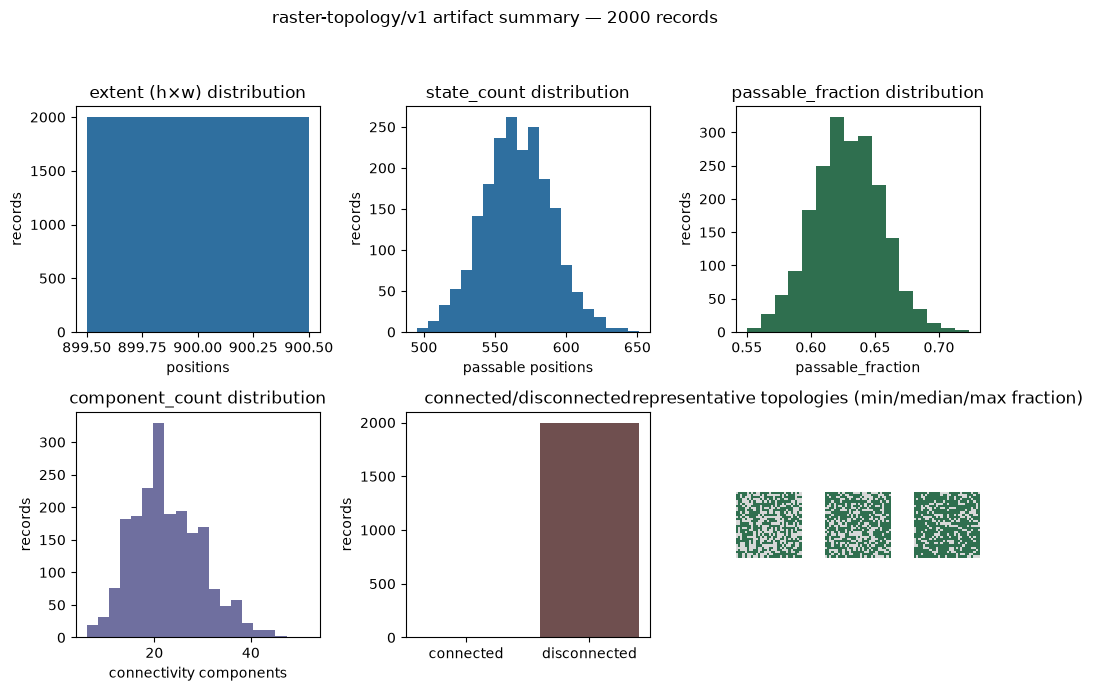

In [2]:
# Artifact-scope summary over the committed record collection. The collection
# schema is derived from the figure's own declared input requirement
# (service.py inspect_artifact_figure); Maze-ND conforms to raster-topology/v1.
from ehp_sn.figures import inspect_artifact_figure

summary = inspect_artifact_figure(
    str(artifact_dir),
    "figure:raster-topology-artifact-summary/v1",
)
proj = summary.projection
print(f"artifact       : {proj.source.artifact_ref}")
print(f"schema         : {proj.source.logical_contract}")
print(f"member records : {len(proj.source.record_ids or ())}")
print("projection_identity:", proj.identity())